# Imports

In [67]:
# Automatically reloads modules before each cell execution, so code changes in library are always propogated.
#reload or load? _ext
%load_ext autoreload
%autoreload 2

%load_ext snakeviz

import networkx as nx
from networkx import MultiDiGraph
import osmnx as ox
import numpy as np
import pandas as pd
from difflib import SequenceMatcher
import concurrent.futures
import copy

from PreProcessing import graph_preprocessing
from NetworkOptimisation import graph_optimisation, heuristic

import graph_util as graph_util
import investigation
import plotting
import constants

ox.settings.useful_tags_way = [
    "bridge", "tunnel", "oneway", "lanes", "highway",
     "width", "name", "name:en", "bicycle", "cycleway"]

GRAPH_PATH = "../Data/master_graph.graphml"
SEED = 72
SAMPLE_K = 1000

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
The snakeviz extension is already loaded. To reload it, use:
  %reload_ext snakeviz


# Generate and save master graph

In [ ]:
#NOTE the length attribute is given in meters
#You project not to fix lengths, but to make sure your geometry math (like areas or spatial intersections) makes sense in linear units.
#Simplify is used to significantly reduce the number of nodes, removing dead ends and combining nodes with no intersections
LOCATION = "Malta (island)"

G_master = graph_preprocessing.load_network(LOCATION)
G_master, gdf_regions_proj, gdf_local_proj = graph_preprocessing.clean_graph(G_master)

Loading OSM networks for Malta (island)...


In [ ]:
ox.io.save_graphml(G_master, filepath=GRAPH_PATH)

gdf_localities_proj.to_pickle("../Data/gdf_localities_proj.pkl")
gdf_regions_proj.to_pickle("../Data/gdf_regions_proj.pkl")

# Load mastergraph

In [2]:
G_master = ox.io.load_graphml(
    filepath=GRAPH_PATH,
    edge_dtypes={
        "car_lanes": int,
        "bike_lanes": int,
        "car_allowed": ox.io._convert_bool_string,
        "bike_allowed": ox.io._convert_bool_string,
        "grade": float,
        "grade_abs": float,
        "risk_factor": float,
    },
    node_dtypes={
        "elevation": float
    })

gdf_localities_proj = pd.read_pickle("../Data/gdf_localities_proj.pkl")
gdf_regions_proj = pd.read_pickle("../Data/gdf_regions_proj.pkl")

# Network Inspection

## Road type classification

In [ ]:
graph_util.summarise_road_type_stats(G_master)

Highway type counts:
residential: 39042
service: 15822
track: 11101
tertiary: 6152
secondary: 5330
non_motorised: 2730
trunk: 2122
primary: 1985
cycleway: 303
-------
bikeway classification type counts:
None: 82021
yes: 2191
designated: 309
no: 45
permissive: 14
permit: 4
private: 3
------
cycleway type counts:
None: 83480
None: 819
no: 201
shared: 30
track: 21
shared_lane: 14
lane: 14
crossing: 8


In [ ]:
print("Nodes:", G_master.number_of_nodes())
print("Edges (total, counts parallel edges separately):", G_master.number_of_edges())
print(G_master.graph)

Nodes: 35755
Edges (total, counts parallel edges separately): 84587
{'created_date': '2025-11-19 13:10:14', 'created_with': 'OSMnx 2.0.5', 'crs': 'EPSG:32633', 'simplified': True}


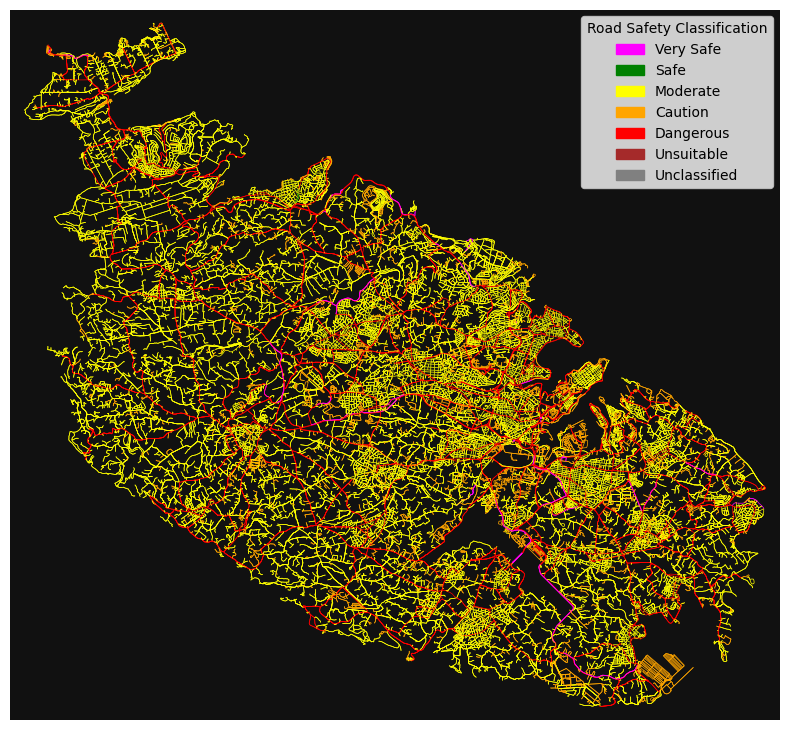

In [ ]:
plotting.plot_road_classification(G_master)

In [ ]:
"""investigation.analyze_parallel_edges(my_graph.G_master)
investigation.compare_parallel_edges(my_graph.G_master)
investigation.plot_parallel_edges(my_graph.G_master)
print("-----")"""

'investigation.analyze_parallel_edges(my_graph.G_master)\ninvestigation.compare_parallel_edges(my_graph.G_master)\ninvestigation.plot_parallel_edges(my_graph.G_master)\nprint("-----")'

## Topology

Fetched elevations for 35755 / 35755 nodes


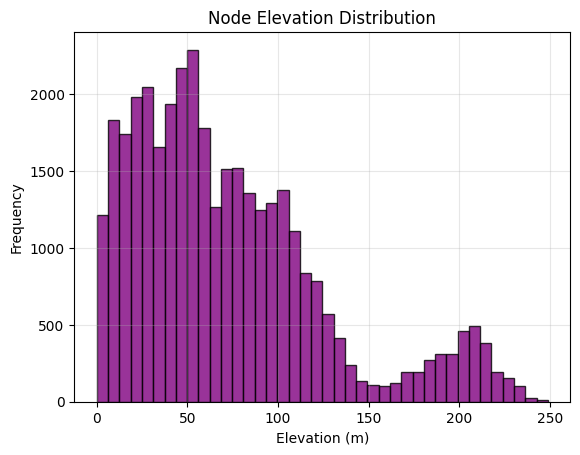

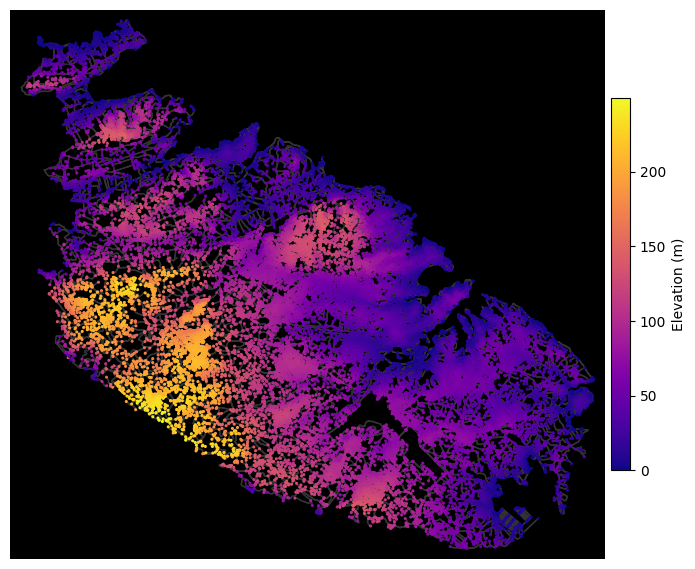

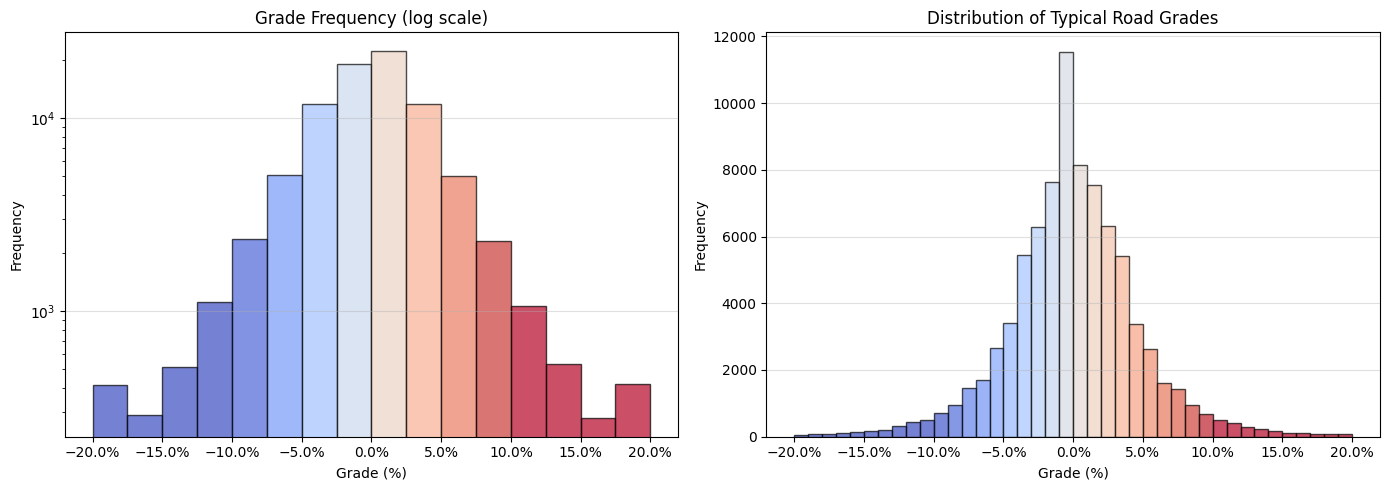

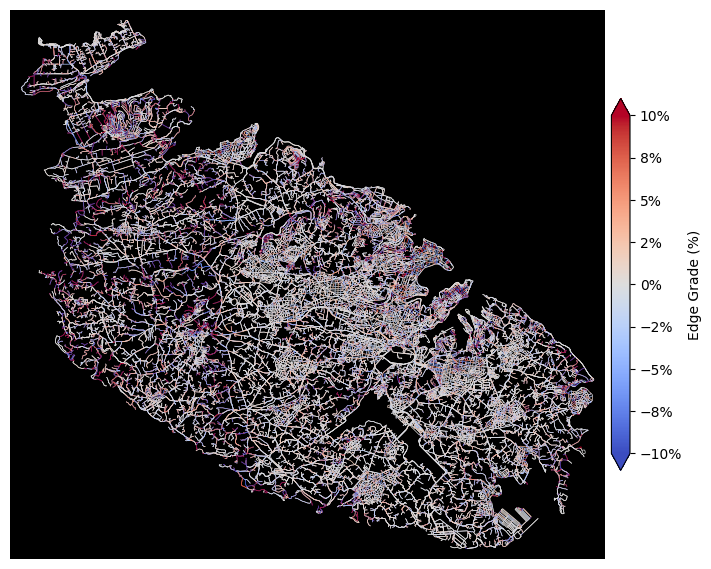

In [ ]:
plotting.plot_elevation(G_master)
plotting.plot_grades(G_master)

## Network statistics

In [ ]:
"""# what sized area does our network cover in square meters?
bike_nodes_proj = ox.convert.graph_to_gdfs(my_graph.G_master, edges=False) #Get only nodes
graph_area_m = bike_nodes_proj.union_all().convex_hull.area
# show some basic stats about the network
stats = ox.stats.basic_stats(my_graph.G_master, area=graph_area_m, clean_int_tol=15)"""

'# what sized area does our network cover in square meters?\nbike_nodes_proj = ox.convert.graph_to_gdfs(my_graph.G_master, edges=False) #Get only nodes\ngraph_area_m = bike_nodes_proj.union_all().convex_hull.area\n# show some basic stats about the network\nstats = ox.stats.basic_stats(my_graph.G_master, area=graph_area_m, clean_int_tol=15)'

In [ ]:
edge_keys = set()
for u,v,data in G_master.edges(data=True):
    edge_keys.update(data.keys())
print(edge_keys)

{'region', 'tunnel', 'bicycle', 'reversed', 'risk_factor', 'geometry', 'oneway', 'bike_lanes', 'car_allowed', 'width', 'grade_abs', 'highway', 'osmid', 'car_lanes', 'length', 'bridge', 'name:en', 'bike_allowed', 'cycleway', 'safety', 'grade', 'locality', 'name'}


# Generating city level subgraphs

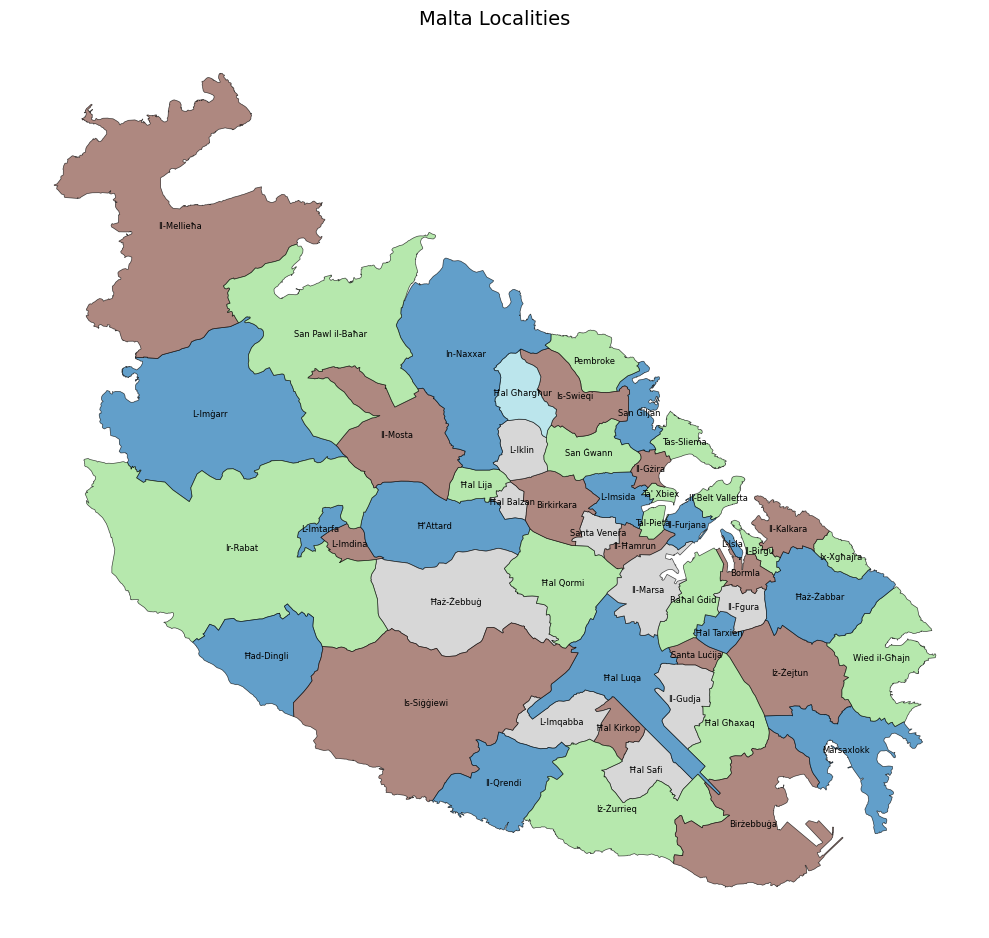

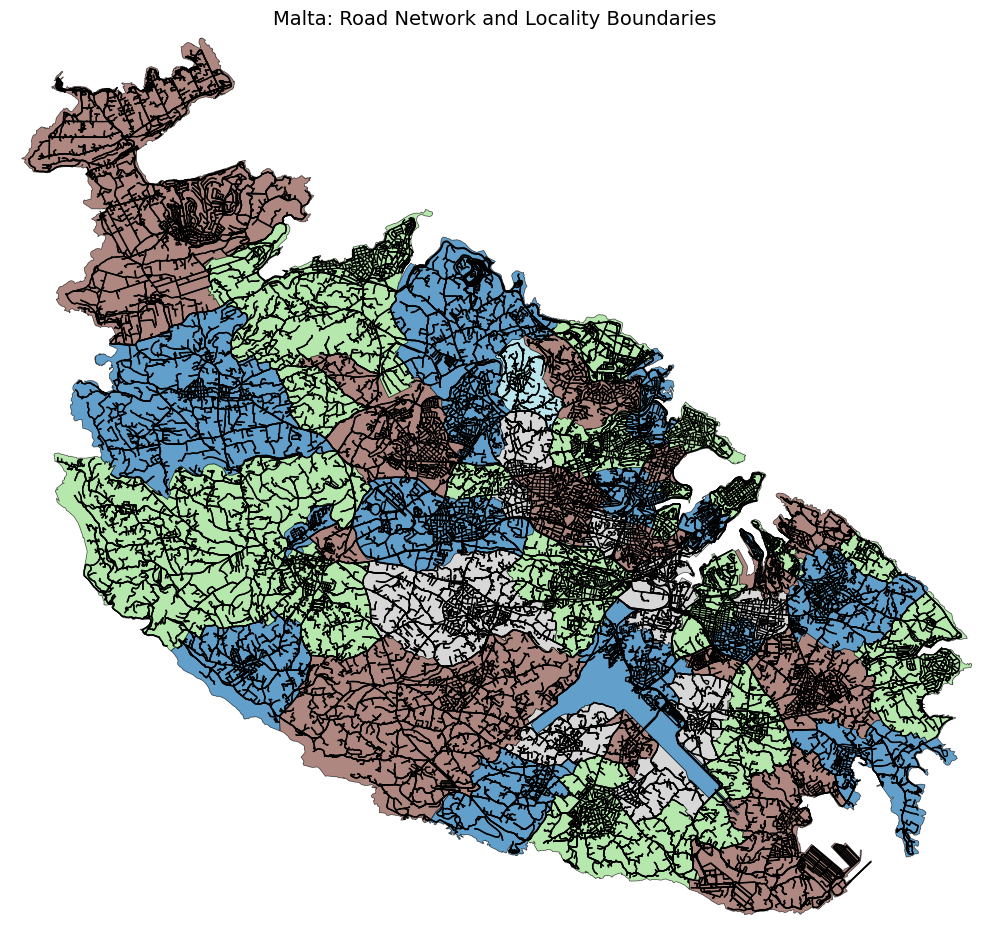

In [3]:
localities = list(gdf_localities_proj["name"])

# Assign distinct colors
gdf_colored = plotting.assign_adjacent_colors(gdf_localities_proj, cmap_name="tab20")

# Plot only polygons
plotting.plot_colored_polygons(gdf_colored, title="Malta Localities")

# Plot polygons + road network overlay
plotting.plot_colored_polygons(
    gdf_colored,
    G=G_master,
    title="Malta: Road Network and Locality Boundaries",
    annotate=False
)

In [4]:
subgraphs = {}
total_nodes = 0
total_edges = 0
for idx, row in gdf_localities_proj.iterrows():
    name = row["name"]

    G_sub = graph_util.make_locality_subgraph(G_master, name)
    subgraphs[name] = G_sub
    total_nodes += len(G_sub.nodes)
    total_edges += len(G_sub.edges)
    print(f"✅ Created subgraph for {name}: {len(G_sub.nodes)} nodes, {len(G_sub.edges)} edges")

print(f"total_nodes{total_nodes}, total_edges{total_edges}")

✅ Created subgraph for Il-Birgu: 242 nodes, 534 edges
✅ Created subgraph for Tas-Sliema: 342 nodes, 644 edges
✅ Created subgraph for L-Imġarr: 1171 nodes, 2591 edges
✅ Created subgraph for Il-Mellieħa: 2634 nodes, 6168 edges
✅ Created subgraph for Il-Ħamrun: 384 nodes, 799 edges
✅ Created subgraph for Santa Venera: 267 nodes, 563 edges
✅ Created subgraph for L-Imdina: 135 nodes, 287 edges
✅ Created subgraph for Ħal Balzan: 190 nodes, 398 edges
✅ Created subgraph for Ħ'Attard: 1120 nodes, 2633 edges
✅ Created subgraph for Ħaż-Żebbuġ: 1239 nodes, 2840 edges
✅ Created subgraph for Ħal Safi: 284 nodes, 635 edges
✅ Created subgraph for Ħal Kirkop: 272 nodes, 575 edges
✅ Created subgraph for L-Imqabba: 394 nodes, 916 edges
✅ Created subgraph for Ħal Qormi: 1152 nodes, 2621 edges
✅ Created subgraph for Il-Gudja: 359 nodes, 838 edges
✅ Created subgraph for Santa Luċija: 226 nodes, 542 edges
✅ Created subgraph for Ħal Tarxien: 359 nodes, 777 edges
✅ Created subgraph for Il-Fgura: 339 nodes, 715

# Topological Metrics

Evaluating how good a network is

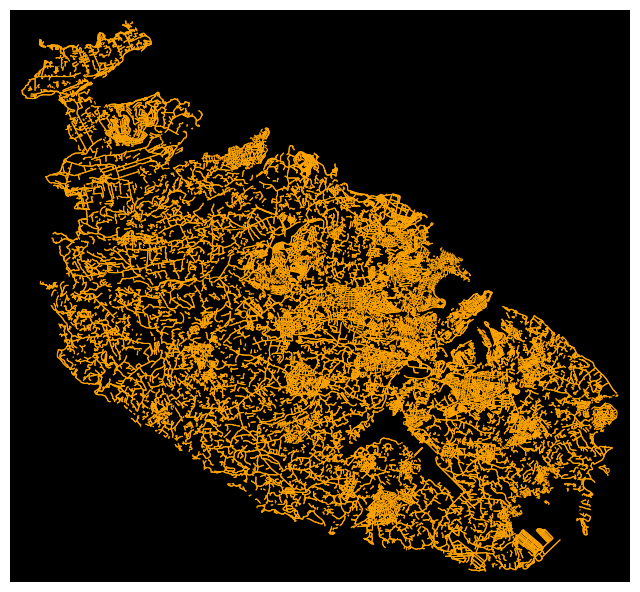

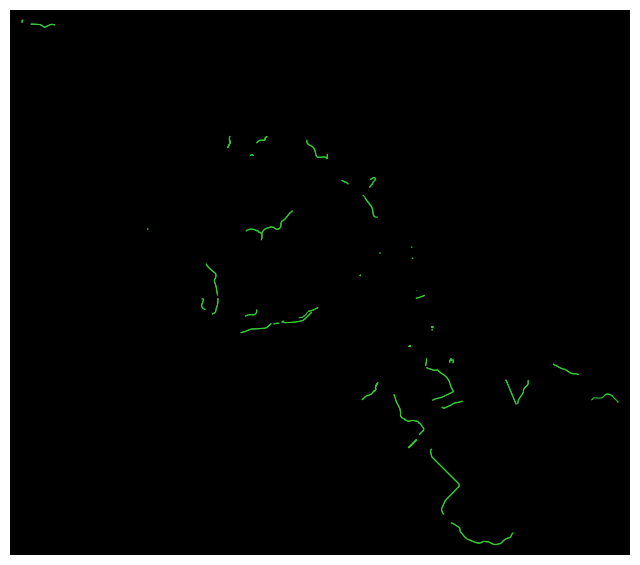

In [ ]:
fig, ax = ox.plot_graph(
    graph_util.make_bikeable_subgraph(G_master),
    node_size=0,
    edge_color="orange",
    edge_linewidth=0.8,
    bgcolor="k"
)

fig, ax = ox.plot_graph(
    graph_util.make_protected_subgraph(G_master),
    node_size=0,
    edge_color="limegreen",
    edge_linewidth=0.8,
    bgcolor="k"
)

In [ ]:
# Directness - measures how efficiently users can travel between two point

# Centrality
#network_evaluation(graph_util.make_protected_subgraph(G_master))
## Degree - number of connections per node

# Optimisation Approaches 

## Heuristic Approaches

Centrality - betweeness and closeness

In [39]:
#%snakeviz -t

heuristics = {
    #"L2S": heuristic.heuristic_L2S,
    "edge_betweenness": heuristic.heuristic_edge_betweenness_centrality,
   # "edge_betweenness2": heuristic.heuristic_edge_betweenness_centrality,

}

all_results = []
for name, func in heuristics.items():
    print(f"Running {name} heuristic")
    df = graph_optimisation.run_global(
        G_master,
        subgraphs,
        heuristic_func=func,
        n_iterations=80,
        max_workers=7,
        parallel=True,
        EVALUATION_MOD=5
    )
    df["heuristic"] = name
    all_results.append(df)

optimised_graph_results_df = pd.concat(all_results, ignore_index=True)
optimised_graph_results_df.sort_values(by=["heuristic", "locality", "iteration"])
optimised_graph_results_df.head()

Running edge_betweenness heuristic


,num_components,lcc_length,mean_edge_betweenness,mean_node_betweenness,mean_node_closeness,mean_degree,locality,iteration,edge_diffs,heuristic
0,14,2.355515e+09,0.001283,0.061233,1,4.567568,Il-Birgu,0,"[(1500108403, 3680870156, 0)]",edge_betweenness
1,14,2.371071e+09,0.001270,0.060733,1,4.576577,Il-Birgu,5,"[(1667367853, 266595939, 0), (1667367853, 2665...",edge_betweenness
2,13,2.374269e+09,0.001268,0.060733,1,4.585586,Il-Birgu,10,"[(5422822281, 246586001, 0), (1633018810, 1633...",edge_betweenness
3,12,2.379003e+09,0.001256,0.060369,1,4.603604,Il-Birgu,15,"[(246585990, 12649685433, 0), (5422822280, 542...",edge_betweenness
4,12,2.379003e+09,0.001256,0.060369,1,4.603604,Il-Birgu,20,"[(1460229762, 3680870159, 0), (7080566158, 368...",edge_betweenness


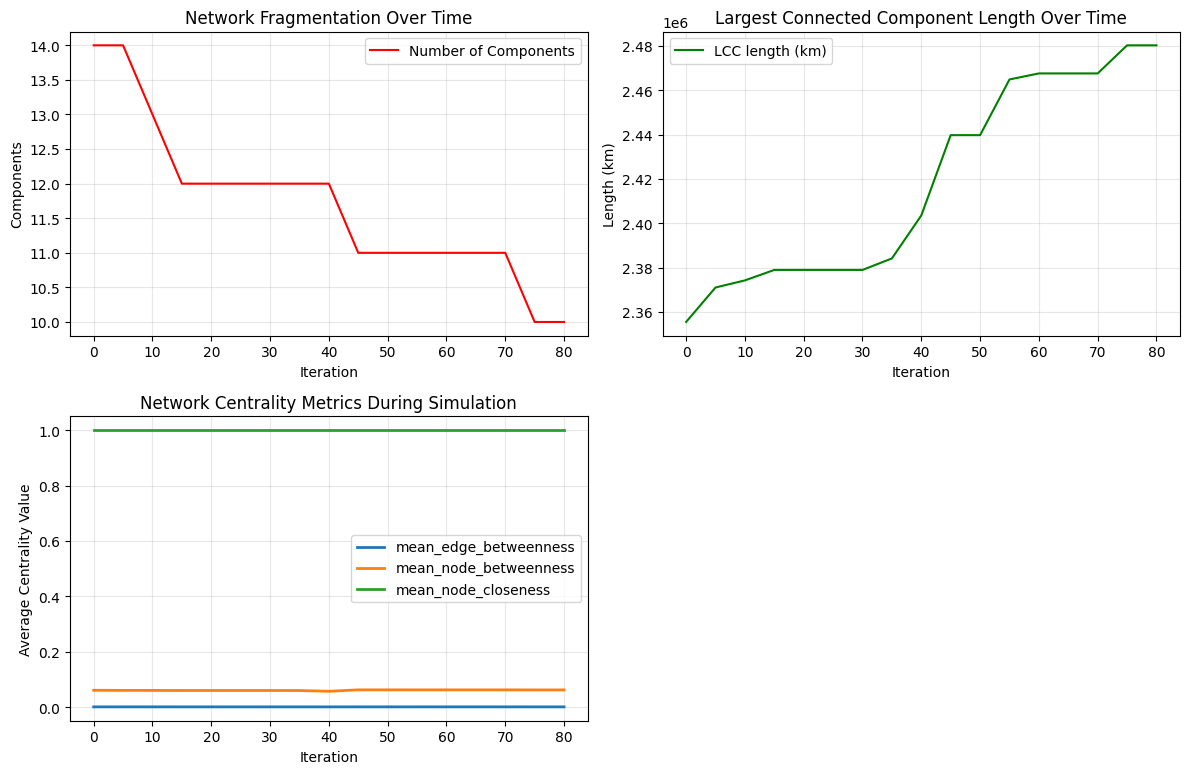

In [47]:
chosen_heuristic = 'edge_betweenness'
chosen_locality = 'Il-Birgu'

optimised_locality_heuristic_df = optimised_graph_results_df[
    (optimised_graph_results_df['heuristic'] == chosen_heuristic) &
    (optimised_graph_results_df['locality'] == chosen_locality)
]
plotting.plot_evaluation(optimised_locality_heuristic_df)

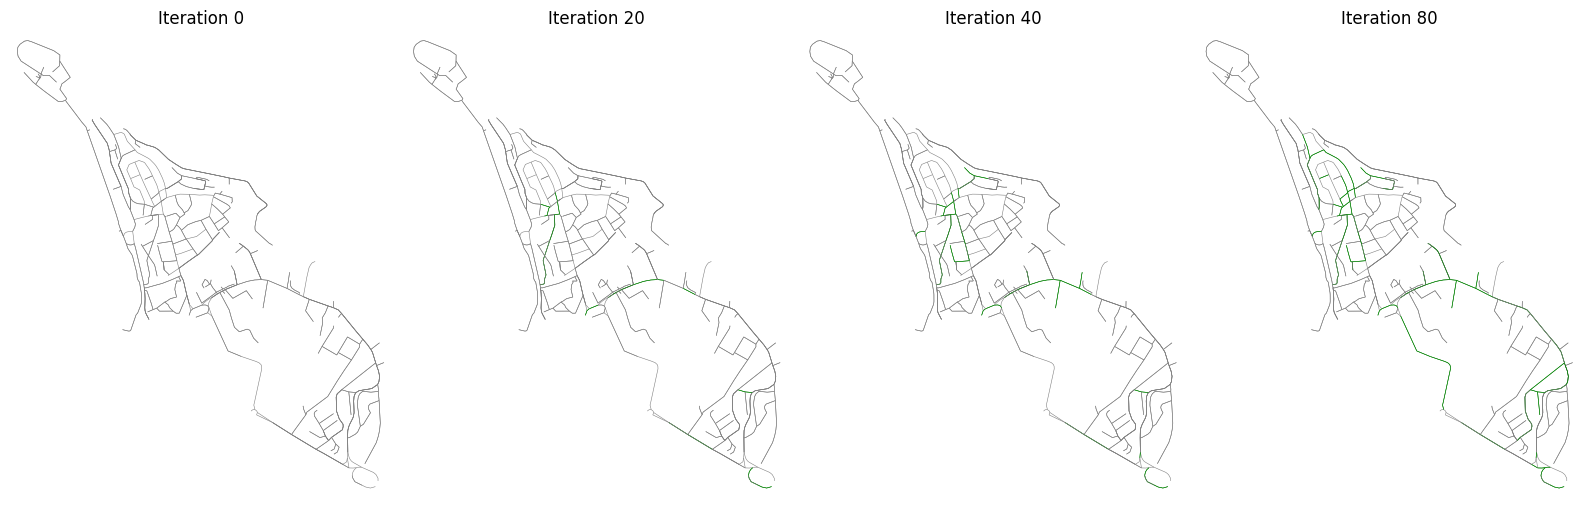

In [69]:
G_locality= graph_util.make_locality_subgraph(G_master,chosen_locality)
plotting.plot_snapshots(G_locality, optimised_locality_heuristic_df["edge_diffs"], snapshot_iters=[0, 20 , 40, 80] )

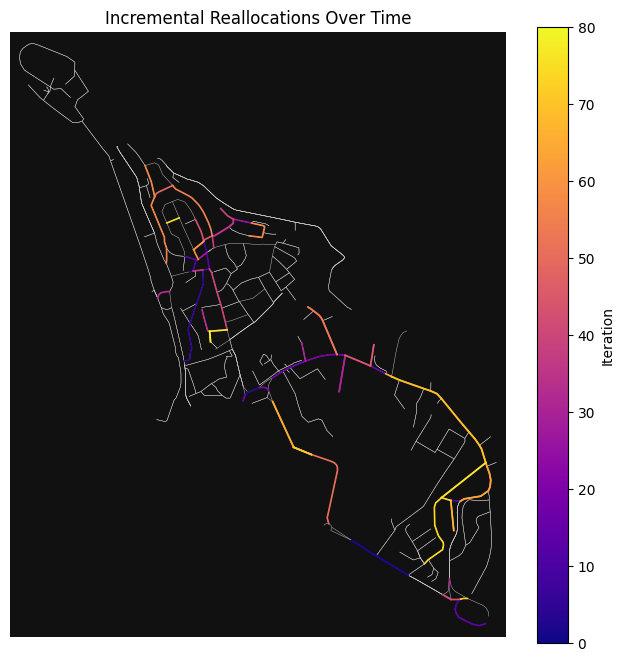

In [70]:
plotting.plot_network_evolution2(G_locality, optimised_locality_heuristic_df["edge_diffs"] )

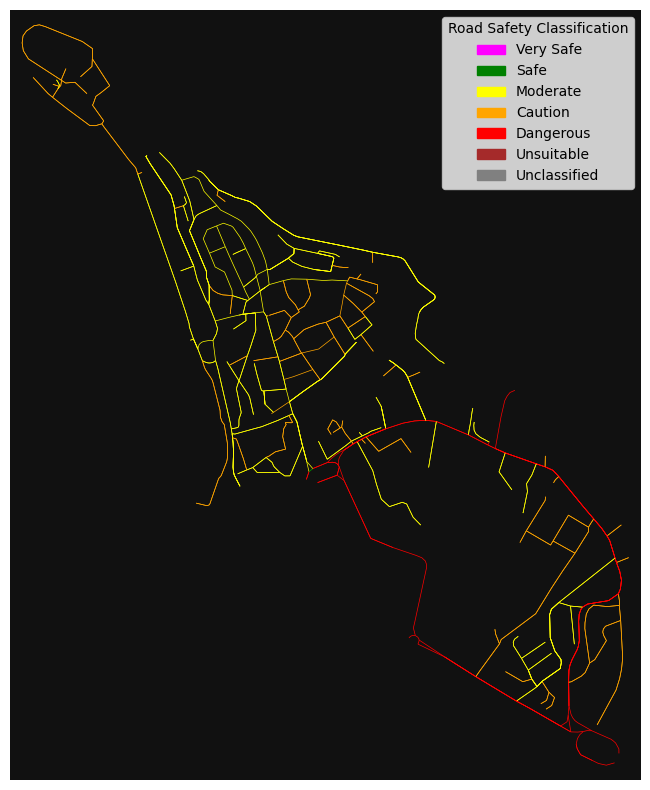

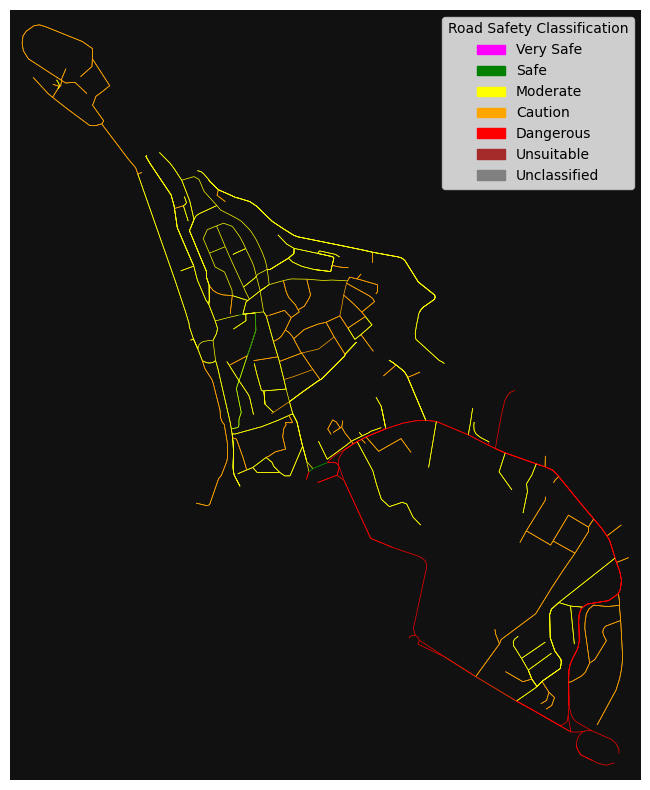

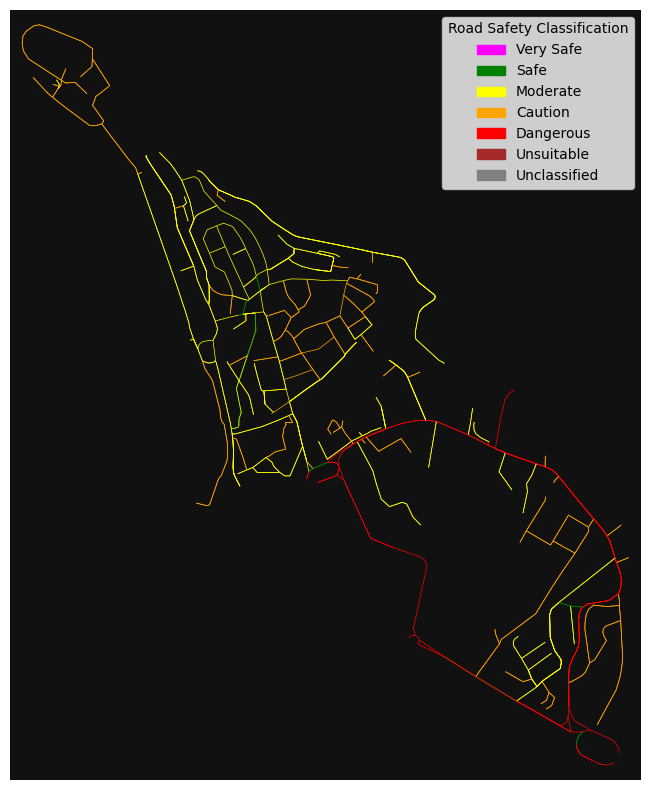

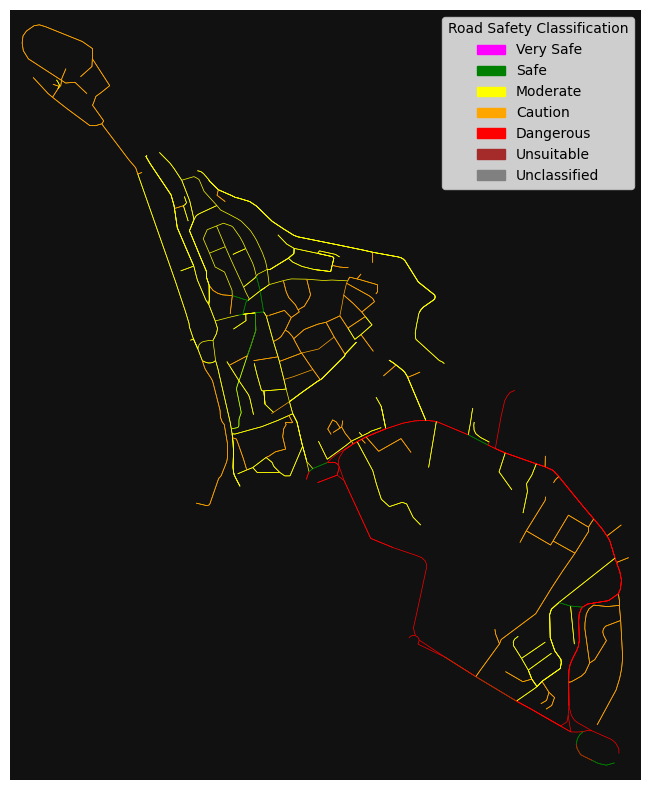

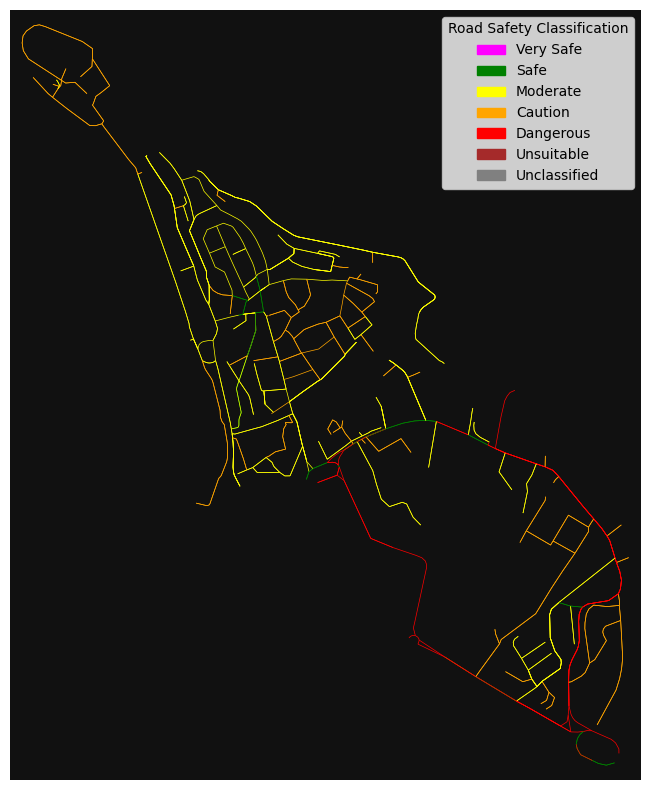

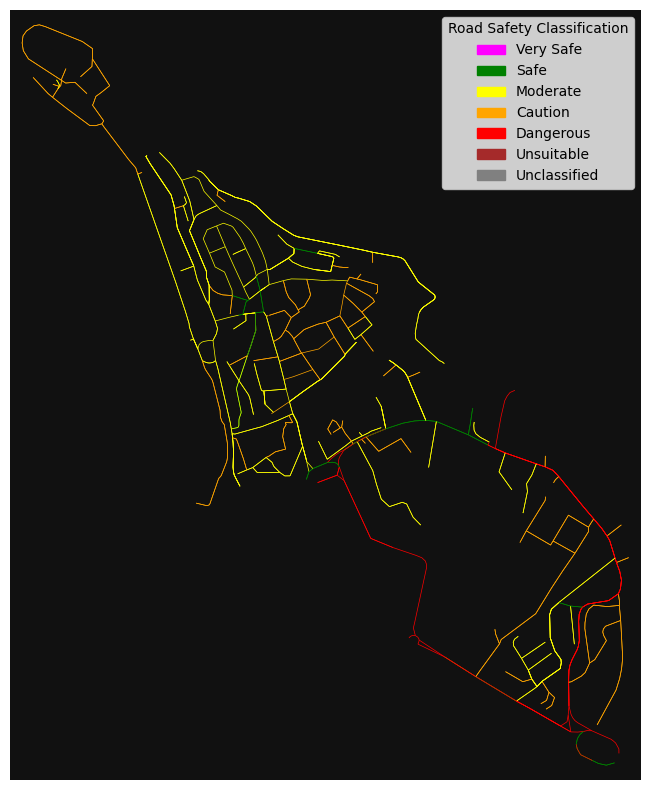

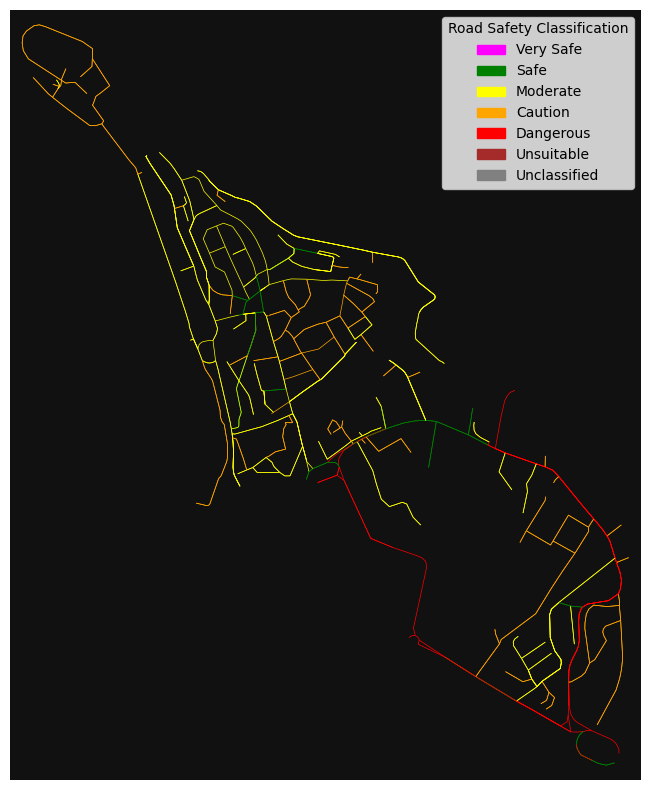

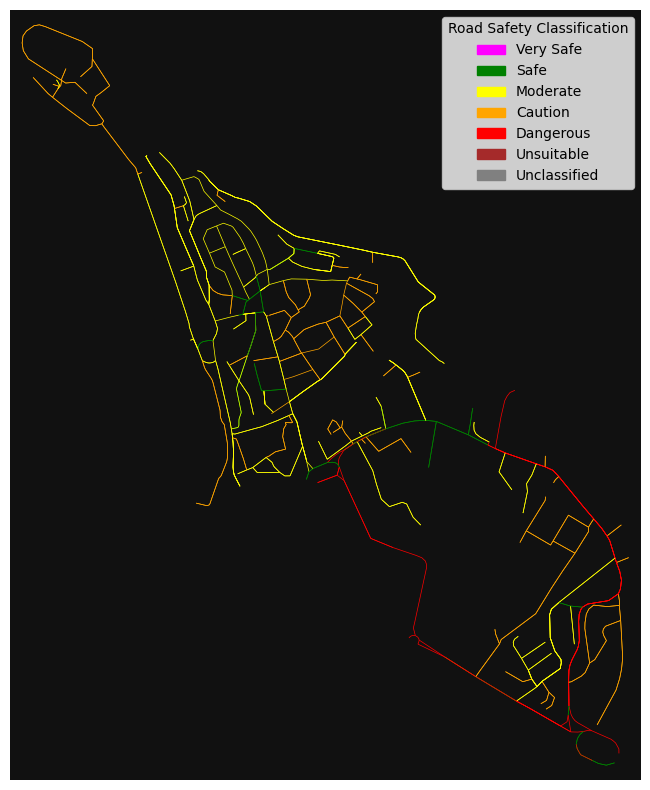

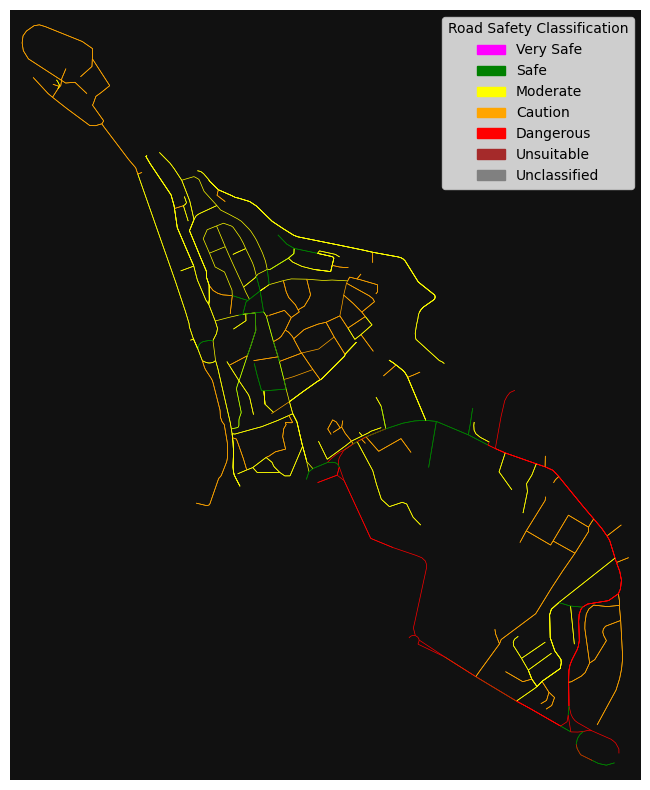

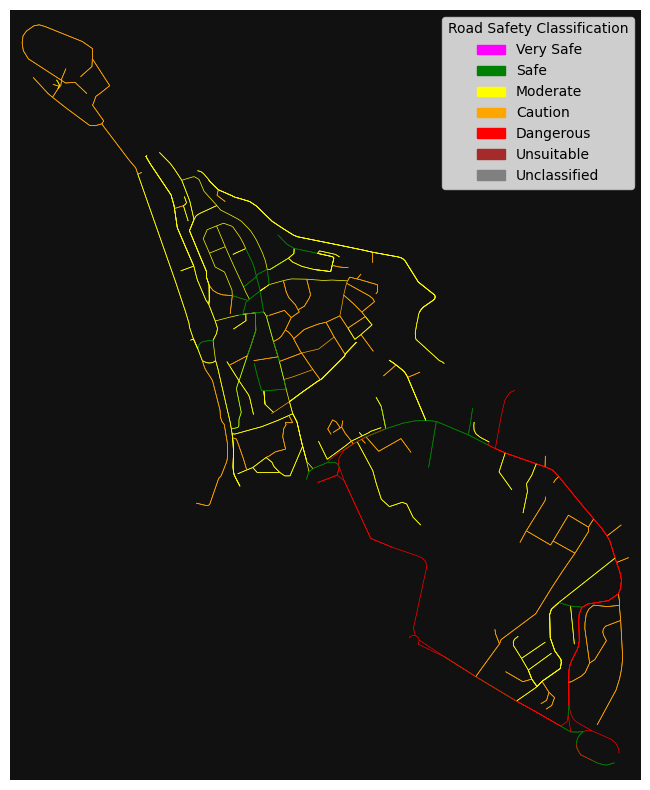

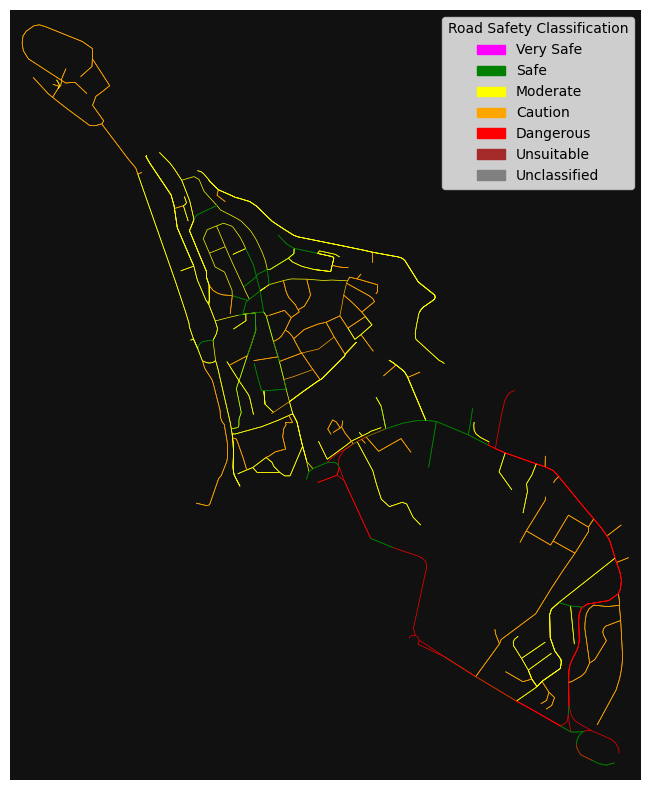

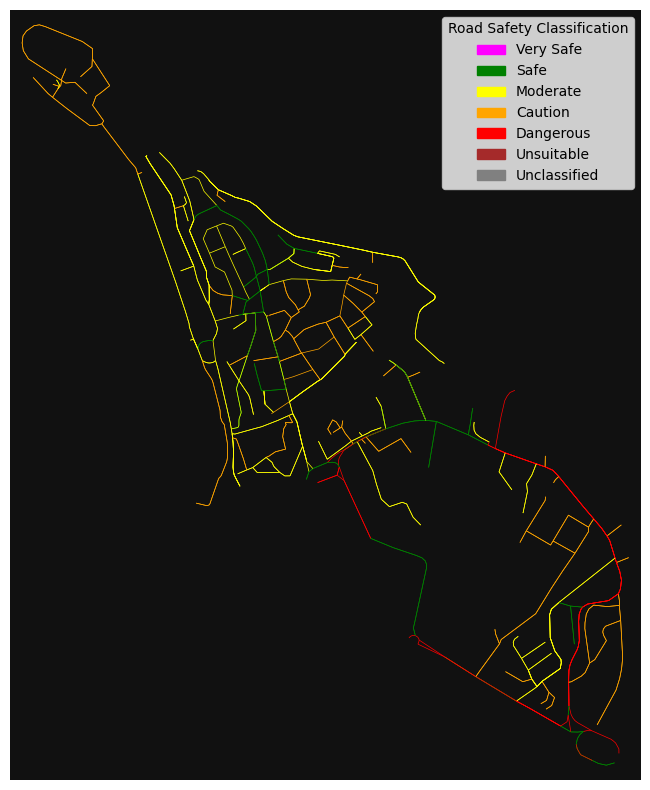

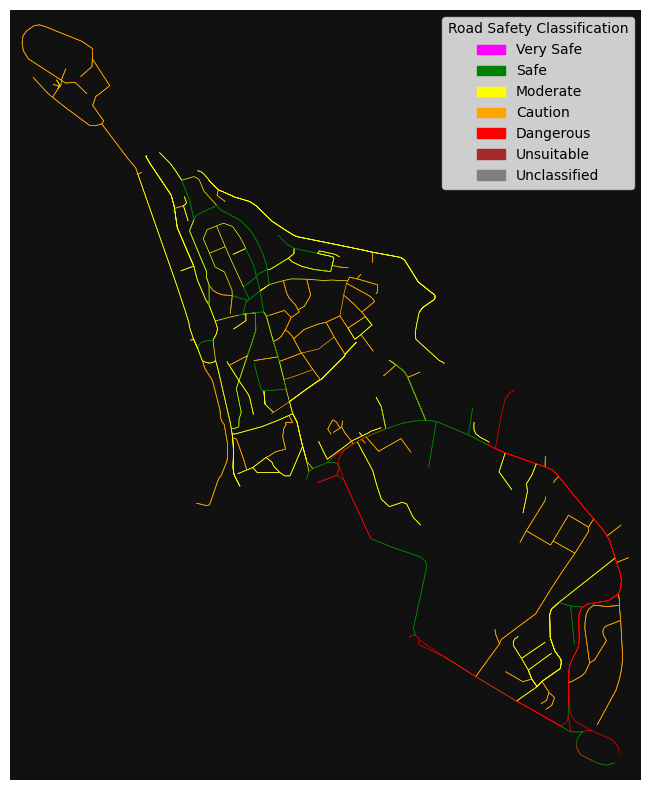

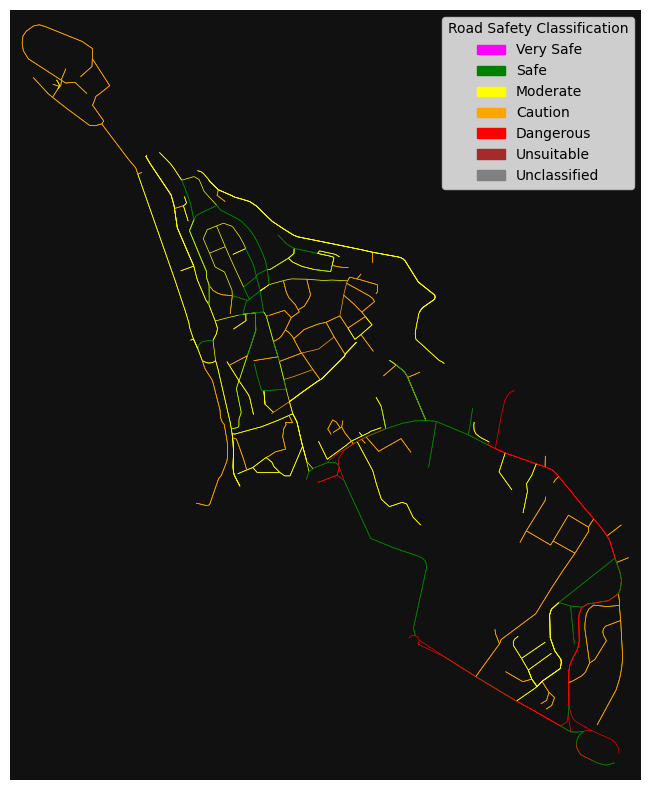

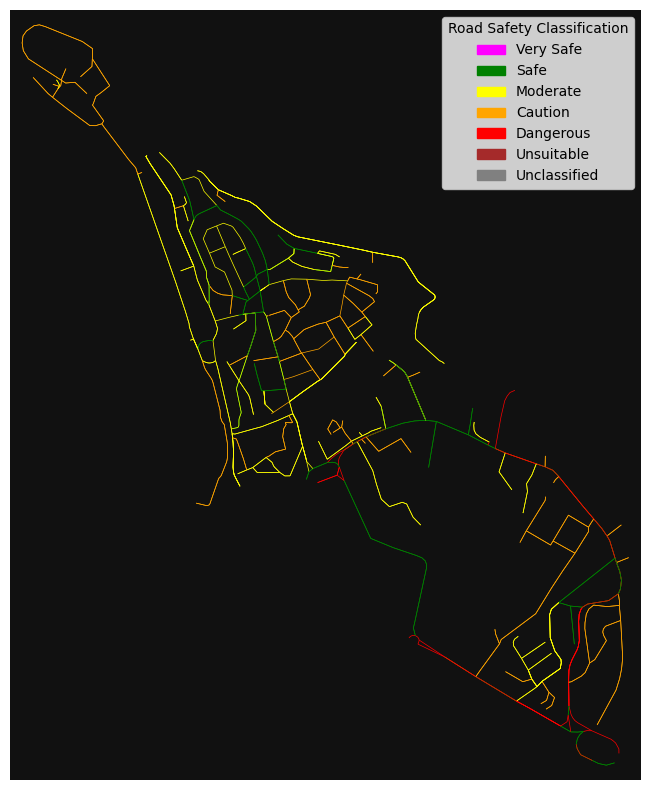

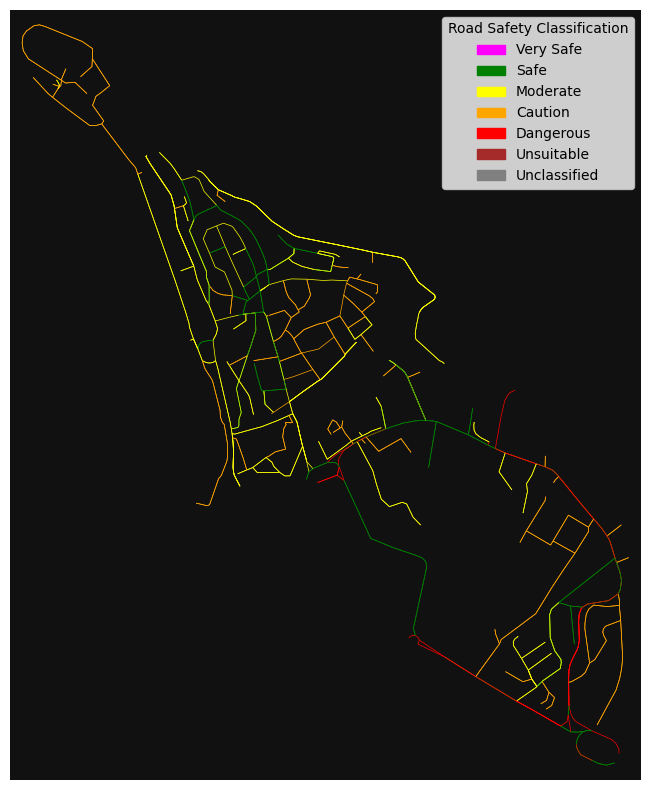

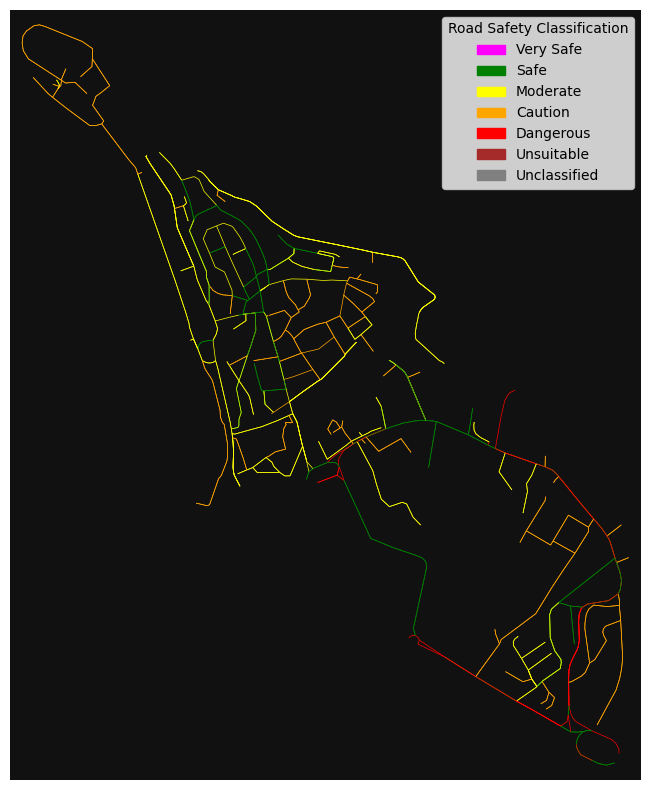

In [44]:
plotting.plot_network_evolution(G_locality, optimised_locality_heuristic_df["edge_diffs"] )

In [45]:
"""%snakeviz -t results = run_simulation(my_graph)
#plotting.plot_evaluation(df_results)"""

'%snakeviz -t results = run_simulation(my_graph)\n#plotting.plot_evaluation(df_results)'